# Задание 3

Анализ продаж электронных устройств за сентябрь 2023 — сентябрь 2024.

In [6]:
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

pd.set_option('display.float_format', '{:,.2f}'.format)
sns.set_theme(style='whitegrid')

data_path = 'data/data_task3/Electronic_sales_Sep2023-Sep2024.csv'
raw_df = pd.read_csv(data_path)
raw_df.head()

,Customer ID,Age,Gender,Loyalty Member,Product Type,SKU,Rating,Order Status,Payment Method,Total Price,Unit Price,Quantity,Purchase Date,Shipping Type,Add-ons Purchased,Add-on Total
0,1000,53,Male,No,Smartphone,SKU1004,2,Cancelled,Credit Card,"5,538.33",791.19,7,2024-03-20,Standard,"Accessory,Accessory,Accessory",40.21
1,1000,53,Male,No,Tablet,SKU1002,3,Completed,Paypal,741.09,247.03,3,2024-04-20,Overnight,Impulse Item,26.09
2,1002,41,Male,No,Laptop,SKU1005,3,Completed,Credit Card,"1,855.84",463.96,4,2023-10-17,Express,NaN,0.00
3,1002,41,Male,Yes,Smartphone,SKU1004,2,Completed,Cash,"3,164.76",791.19,4,2024-08-09,Overnight,"Impulse Item,Impulse Item",60.16
4,1003,75,Male,Yes,Smartphone,SKU1001,5,Completed,Cash,41.50,20.75,2,2024-05-21,Express,Accessory,35.56


## Задание 1

Пропуски в суммах дополнительных покупок считаются нулевыми, а пропуски в способе оплаты заполняются значением Unknown. При одинаковой частоте способов оплаты выбирается лексикографически первый.

In [7]:
task1_df = raw_df.copy()
task1_df['Total Price'] = pd.to_numeric(task1_df['Total Price'], errors='coerce').fillna(0)
task1_df['Add-on Total'] = pd.to_numeric(task1_df['Add-on Total'], errors='coerce').fillna(0)
task1_df['Payment Method'] = task1_df['Payment Method'].fillna('Unknown')

payment_counts = (
    task1_df.groupby(['Customer ID', 'Payment Method']).size()
    .reset_index(name='count')
    .sort_values(['Customer ID', 'count', 'Payment Method'], ascending=[True, False, True])
    .drop_duplicates('Customer ID')
    .rename(columns={'Payment Method': 'preferred_payment'})
)

customer_summary = (
    task1_df.groupby('Customer ID', as_index=False)
    .agg(
        total_spent=('Total Price', 'sum'),
        addons_spent=('Add-on Total', 'sum'),
        orders_count=('Customer ID', 'size'),
    )
    .merge(payment_counts[['Customer ID', 'preferred_payment']], on='Customer ID', how='left')
    .rename(columns={'Customer ID': 'customer_id'})
    .sort_values('total_spent', ascending=False)
    .reset_index(drop=True)
)

customer_summary[['customer_id', 'preferred_payment', 'total_spent', 'addons_spent', 'orders_count']].head(10)

,customer_id,preferred_payment,total_spent,addons_spent,orders_count
0,16357,Bank Transfer,"34,563.70",495.19,7
1,16863,PayPal,"33,035.92",486.17,5
2,13813,Credit Card,"31,830.16",268.64,5
3,11476,PayPal,"31,077.61",301.59,5
4,12276,Bank Transfer,"30,961.18",329.07,6
5,13635,Credit Card,"30,260.36",480.73,5
6,12749,Credit Card,"29,394.56",619.43,5
7,15399,PayPal,"29,084.88",305.39,3
8,12319,Bank Transfer,"27,352.32",226.38,3
9,19996,Bank Transfer,"27,296.78",432.12,6


## Задание 2

В очистке удаляются строки без идентификатора покупателя или даты, а также заказы с отрицательной или нулевой общей либо единичной ценой. Пропуски в дополнительных покупках заменяются нулём, в категориальных признаках — Unknown. Для месяцев без дополнительных покупок в диапазоне дат создаётся строка с нулевой выручкой.

In [8]:
def clean(df):
    result = df.copy()
    result['Purchase Date'] = pd.to_datetime(result['Purchase Date'], errors='coerce')

    for column in ['Total Price', 'Unit Price', 'Add-on Total']:
        result[column] = pd.to_numeric(result[column], errors='coerce')

    result['Add-on Total'] = result['Add-on Total'].fillna(0)
    for column in ['Payment Method', 'Shipping Type', 'Product Type', 'Add-ons Purchased']:
        result[column] = result[column].fillna('Unknown')

    result = result.dropna(subset=['Customer ID', 'Purchase Date'])
    result = result[(result['Total Price'] > 0) & (result['Unit Price'] > 0) & (result['Add-on Total'] >= 0)]
    return result.reset_index(drop=True)


def build_metrics(df):
    revenue_by_shipping = (
        df.groupby('Shipping Type', as_index=False)['Total Price'].sum()
        .rename(columns={'Shipping Type': 'shipping_method', 'Total Price': 'revenue'})
        .sort_values('revenue', ascending=False)
    )
    revenue_by_product = (
        df.groupby('Product Type', as_index=False)['Total Price'].sum()
        .rename(columns={'Product Type': 'product_type', 'Total Price': 'revenue'})
        .sort_values('revenue', ascending=False)
    )

    monthly = df.assign(month=df['Purchase Date'].dt.to_period('M'))
    quarterly = df.assign(quarter=df['Purchase Date'].dt.to_period('Q'))

    addons_by_month = (
        monthly.groupby('month')['Add-on Total'].sum()
        .rename('addons_revenue').reset_index()
    )
    addons_by_quarter = (
        quarterly.groupby('quarter')['Add-on Total'].sum()
        .rename('addons_revenue').reset_index()
    )

    if not df.empty:
        month_index = pd.period_range(monthly['month'].min(), monthly['month'].max(), freq='M')
        addons_by_month = (
            addons_by_month.set_index('month').reindex(month_index, fill_value=0)
            .rename_axis('month').reset_index()
        )

    cohort_data = monthly[['Customer ID', 'month', 'Total Price']].copy()
    cohort_data['cohort'] = cohort_data.groupby('Customer ID')['month'].transform('min')
    cohort_data['lifetime_month'] = (
        (cohort_data['month'].dt.year - cohort_data['cohort'].dt.year) * 12
        + cohort_data['month'].dt.month - cohort_data['cohort'].dt.month
    )
    cohort_data = cohort_data[cohort_data['lifetime_month'].between(0, 3)]

    cohort_revenue = (
        cohort_data.pivot_table(index='cohort', columns='lifetime_month', values='Total Price', aggfunc='sum')
        .reindex(columns=range(4)).rename_axis(None, axis=1)
    )
    cohort_customers = (
        cohort_data.pivot_table(index='cohort', columns='lifetime_month', values='Customer ID', aggfunc='nunique')
        .reindex(columns=range(4)).rename_axis(None, axis=1)
    )

    return {
        'revenue_by_shipping': revenue_by_shipping,
        'revenue_by_product': revenue_by_product,
        'addons_by_month': addons_by_month,
        'addons_by_quarter': addons_by_quarter,
        'cohort_revenue': cohort_revenue,
        'cohort_customers': cohort_customers,
    }


df = clean(raw_df)
metrics = build_metrics(df)
print(f'Строк до очистки: {len(raw_df):,}')
print(f'Строк после очистки: {len(df):,}')

Строк до очистки: 20,000
Строк после очистки: 20,000


In [9]:
display(metrics['revenue_by_shipping'])
display(metrics['revenue_by_product'])
display(metrics['addons_by_month'].head())
display(metrics['addons_by_quarter'])
display(metrics['cohort_revenue'])
display(metrics['cohort_customers'])

,shipping_method,revenue
4,Standard,"21,343,073.55"
0,Expedited,"12,437,526.21"
3,Same Day,"12,432,024.82"
2,Overnight,"8,704,828.17"
1,Express,"8,685,215.62"


,product_type,revenue
2,Smartphone,"21,516,754.69"
3,Smartwatch,"14,036,273.06"
1,Laptop,"12,296,239.97"
4,Tablet,"11,712,000.41"
0,Headphones,"4,041,400.24"


,month,addons_revenue
0,2023-09,"8,012.62"
1,2023-10,"37,837.12"
2,2023-11,"34,888.81"
3,2023-12,"33,509.15"
4,2024-01,"136,195.16"


,quarter,addons_revenue
0,2023Q3,"8,012.62"
1,2023Q4,"106,235.08"
2,2024Q1,"381,298.34"
3,2024Q2,"382,681.69"
4,2024Q3,"366,669.23"


,0,1,2,3
cohort,,,,
2023-09,"481,961.79","50,514.74","47,257.20","51,120.20"
2023-10,"2,267,951.61","155,302.95","239,168.06","199,974.25"
2023-11,"1,865,873.99","128,478.44","186,910.97","98,007.62"
2023-12,"1,561,933.63","154,981.79","105,574.15","114,670.83"
2024-01,"6,034,006.07","563,400.17","723,336.79","672,185.51"
2024-02,"4,734,162.29","491,320.81","527,889.65","607,050.30"
2024-03,"4,631,455.70","550,615.28","488,574.18","489,712.08"
2024-04,"4,122,813.88","396,920.86","511,530.09","490,340.42"
2024-05,"3,870,243.83","377,504.74","515,389.20","345,730.60"


,0,1,2,3
cohort,,,,
2023-09,185.00,19.00,19.00,18.00
2023-10,852.00,61.00,77.00,72.00
2023-11,686.00,54.00,63.00,47.00
2023-12,614.00,54.00,45.00,52.00
2024-01,"1,722.00",163.00,189.00,176.00
2024-02,"1,386.00",130.00,149.00,155.00
2024-03,"1,330.00",147.00,145.00,149.00
2024-04,"1,170.00",120.00,132.00,123.00
2024-05,"1,097.00",106.00,129.00,104.00


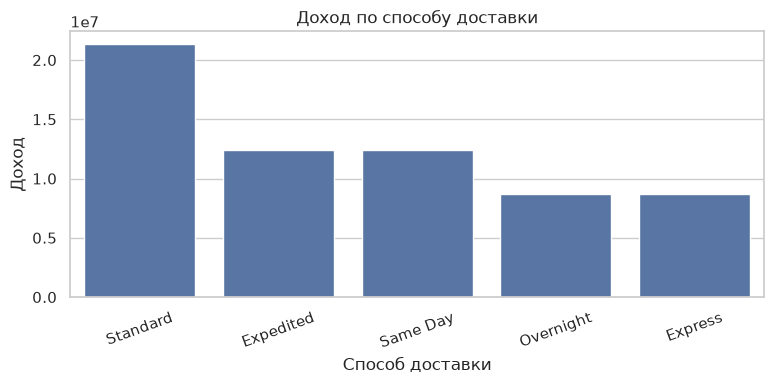

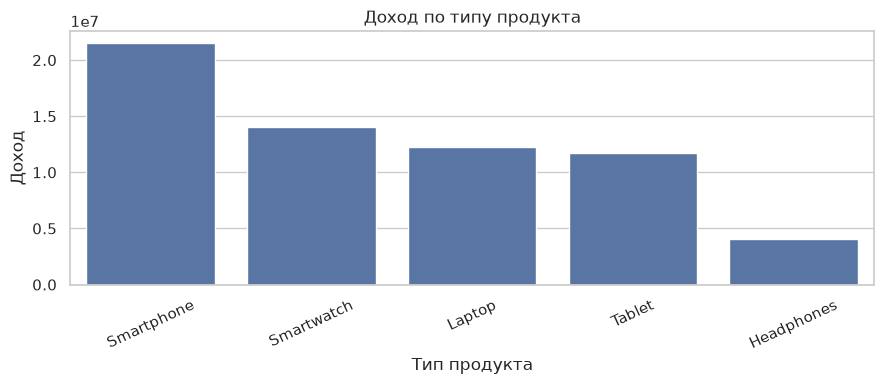

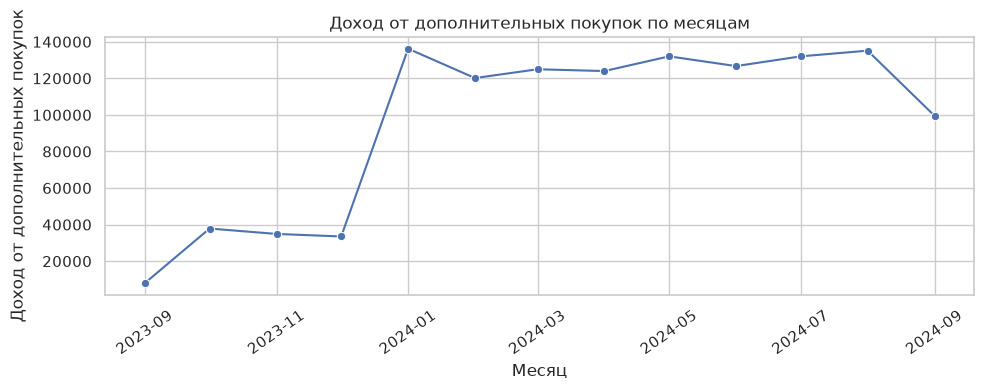

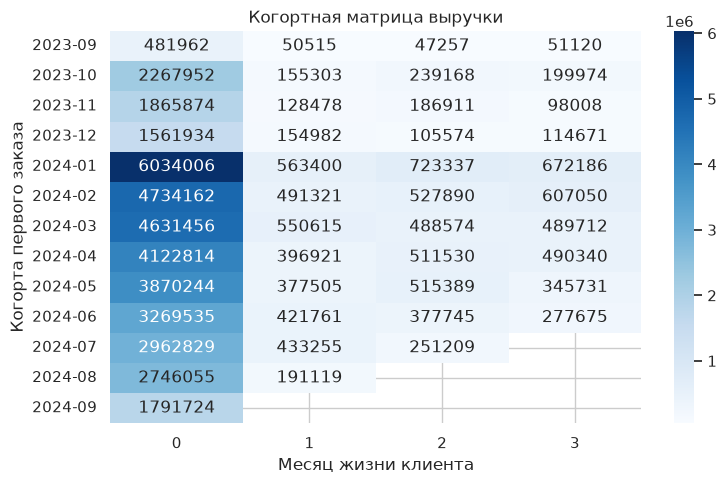

In [10]:
fig, ax = plt.subplots(figsize=(8, 4))
sns.barplot(data=metrics['revenue_by_shipping'], x='shipping_method', y='revenue', ax=ax)
ax.set_title('Доход по способу доставки')
ax.set_xlabel('Способ доставки')
ax.set_ylabel('Доход')
plt.xticks(rotation=20)
plt.tight_layout()
plt.show()

fig, ax = plt.subplots(figsize=(9, 4))
sns.barplot(data=metrics['revenue_by_product'], x='product_type', y='revenue', ax=ax)
ax.set_title('Доход по типу продукта')
ax.set_xlabel('Тип продукта')
ax.set_ylabel('Доход')
plt.xticks(rotation=25)
plt.tight_layout()
plt.show()

addons_plot = metrics['addons_by_month'].copy()
addons_plot['month'] = addons_plot['month'].dt.to_timestamp()

fig, ax = plt.subplots(figsize=(10, 4))
sns.lineplot(data=addons_plot, x='month', y='addons_revenue', marker='o', ax=ax)
ax.set_title('Доход от дополнительных покупок по месяцам')
ax.set_xlabel('Месяц')
ax.set_ylabel('Доход от дополнительных покупок')
plt.xticks(rotation=35)
plt.tight_layout()
plt.show()

fig, ax = plt.subplots(figsize=(8, 5))
sns.heatmap(metrics['cohort_revenue'], cmap='Blues', annot=True, fmt='.0f', ax=ax)
ax.set_title('Когортная матрица выручки')
ax.set_xlabel('Месяц жизни клиента')
ax.set_ylabel('Когорта первого заказа')
plt.tight_layout()
plt.show()

## Выводы

По столбчатым диаграммам можно сравнить вклад способов доставки и продуктовых категорий в общий доход. Линейный график показывает изменение выручки от дополнительных покупок по месяцам. Тепловая карта позволяет увидеть, как выручка каждой когорты меняется после первого месяца.